In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

# ==========================================
# OPACUS IMPORTS
# ==========================================
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

# ==========================================
# CONFIGURATION & HYPERPARAMETERS
# ==========================================
# Path from your simple notebook
DATA_PATH = '../../data/brain_tumor_dataset'

# DP SETTINGS
# ---------------------------------------------------------
# STEP 1: Set this to 0.0 to verify the pipeline works (No Privacy, High Utility)
# STEP 2: Increase to 1.0, 1.5, etc. to see degradation (High Privacy, Lower Utility)
NOISE_MULTIPLIER = 0.0

# Controls how much a single image can influence the model.
# If gradients > this, they are chopped off.
# Too low = slow learning. Too high = noise has to be larger to mask it.
MAX_GRAD_NORM = 1.2

# Standard Params
IMG_SIZE = 64
LATENT_DIM = 64
MAX_FILTERS = 128
EPOCHS = 900  # Extended training with scheduler/early checkpointing
BATCH_SIZE = 64 # Opacus likes smaller logical batches, but 64 is fine
LR = 1e-3
BETA = 0.5  # β-VAE scaling; increase later for more disentanglement
CHECKPOINT_PATH = "brain_vae_dp_simple2_best.pt"
SAMPLE_COUNT = 5

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"DP Settings -> Noise: {NOISE_MULTIPLIER}, Max Grad Norm: {MAX_GRAD_NORM}")


Using device: mps
DP Settings -> Noise: 0.5, Max Grad Norm: 1.2


In [ ]:

# ==========================================
# DATA LOADING
# ==========================================
def load_images(data_folder, image_size=64):
    """Load JPG images from 'yes' and 'no' subfolders and return numpy arrays."""
    X, y = [], []
    label_mapping = {"no": 0, "yes": 1}

    # Ensure transforms match the model input requirements
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])

    if not os.path.exists(data_folder):
        print(f"Data folder {data_folder} not found. Generating DUMMY data for testing.")
        # Generate random noise data if folder is missing so script runs
        return np.random.rand(100, 3, image_size, image_size).astype(np.float32), np.zeros(100)

    for class_name, label in label_mapping.items():
        class_folder = os.path.join(data_folder, class_name)
        if not os.path.isdir(class_folder):
            continue

        for filename in os.listdir(class_folder):
            if filename.lower().endswith((".jpg", ".jpeg")):
                file_path = os.path.join(class_folder, filename)
                try:
                    with Image.open(file_path) as img:
                        image = img.convert("RGB")
                    image_tensor = transform(image)
                    X.append(image_tensor.numpy())
                    y.append(label)
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    return np.array(X), np.array(y)

# Load Data
X_raw, y_raw = load_images(DATA_PATH, image_size=IMG_SIZE)
X = torch.tensor(X_raw, dtype=torch.float32)
y = torch.tensor(y_raw, dtype=torch.long)
LABEL_NAMES = {0: "no", 1: "yes"}
class_counts = {LABEL_NAMES[int(lbl)]: int((y == lbl).sum()) for lbl in torch.unique(y)}
print(f"Data loaded: {X.shape} | label counts: {class_counts}")

# Create DataLoader (keep labels for analysis even if training only uses images)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


Data loaded: torch.Size([251, 3, 64, 64]) | label counts: {'no': 97, 'yes': 154}


In [4]:

# ==========================================
# MODEL DEFINITION (Original Architecture)
# ==========================================
class Encoder(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, device, img_size=64):
        super().__init__()
        self.num_latent_dims = num_latent_dims
        self.num_img_channels = num_img_channels
        self.max_num_filters = max_num_filters
        self.device = device

        num_filters_1 = max_num_filters // 4
        num_filters_2 = max_num_filters // 2
        num_filters_3 = max_num_filters

        self.conv1 = nn.Conv2d(num_img_channels, num_filters_1, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(num_filters_1, num_filters_2, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(num_filters_2, num_filters_3, kernel_size=3, stride=2, padding=1)

        # Note: BatchNorm is NOT DP-compliant. We will fix this automatically later using ModuleValidator.
        self.bn1 = nn.BatchNorm2d(num_filters_1)
        self.bn2 = nn.BatchNorm2d(num_filters_2)
        self.bn3 = nn.BatchNorm2d(num_filters_3)

        flattened_dim = num_filters_3 * (img_size // 8) * (img_size // 8)
        self.proj_mu = nn.Linear(flattened_dim, num_latent_dims)
        self.proj_log_var = nn.Linear(flattened_dim, num_latent_dims)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        x = F.leaky_relu(self.bn3(self.conv3(x)))
        x = torch.flatten(x, 1)

        mu = self.proj_mu(x)
        logvar = self.proj_log_var(x)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = eps.mul(sigma).add_(mu)

        # Standard VAE KL Divergence
        # Opacus is fine with this as long as operations are per-sample capable or reduction happens at the end
        self.kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return z

class Decoder(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, img_size=64):
        super().__init__()
        self.num_latent_dims = num_latent_dims
        self.num_img_channels = num_img_channels
        self.max_num_filters = max_num_filters

        num_filters_1 = max_num_filters
        num_filters_2 = max_num_filters // 2
        num_filters_3 = max_num_filters // 4

        self.input_shape = [num_filters_1, img_size // 8, img_size // 8]
        flattened_dim = num_filters_1 * (img_size // 8) * (img_size // 8)

        self.lin1 = nn.Linear(num_latent_dims, flattened_dim)

        self.conv1 = nn.ConvTranspose2d(num_filters_1, num_filters_2, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv2 = nn.ConvTranspose2d(num_filters_2, num_filters_3, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv3 = nn.ConvTranspose2d(num_filters_3, num_img_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

        # BatchNorm will be replaced by GroupNorm automatically
        self.bn1 = nn.BatchNorm2d(num_filters_2)
        self.bn2 = nn.BatchNorm2d(num_filters_3)

    def forward(self, z):
        x = self.lin1(z)
        x = x.view(-1, *self.input_shape)
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        x = torch.sigmoid(self.conv3(x))
        return x

class VAE(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, device, img_size=64):
        super().__init__()
        self.encoder = Encoder(num_latent_dims, num_img_channels, max_num_filters, device, img_size)
        self.decoder = Decoder(num_latent_dims, num_img_channels, max_num_filters, img_size)
        self.kl_div = 0

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        self.kl_div = self.encoder.kl_div
        return x_recon

    def decode(self, z):
        return self.decoder(z)


In [ ]:

# ==========================================
# SETUP & DP CONVERSION
# ==========================================

# 1. Initialize Model
model = VAE(LATENT_DIM, 3, MAX_FILTERS, device, IMG_SIZE)

# 2. Fix incompatible layers (Opacus doesn't like BatchNorm because it mixes batch data)
# ModuleValidator finds BatchNorms and replaces them with GroupNorms automatically
errors = ModuleValidator.validate(model, strict=False)
if len(errors) > 0:
    print(f"Opacus found {len(errors)} incompatible layers (BatchNorm). Fixing them...")
    model = ModuleValidator.fix(model)
    print("Model fixed. BatchNorms replaced with GroupNorms.")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 3. Attach Privacy Engine
privacy_engine = PrivacyEngine()

model, optimizer, dataloader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=dataloader,
    noise_multiplier=NOISE_MULTIPLIER,
    max_grad_norm=MAX_GRAD_NORM,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=15, threshold=1e-3, min_lr=1e-5
)

print(f"Privacy Engine attached. Noise: {NOISE_MULTIPLIER}")

# ==========================================
# TRAINING LOOP
# ==========================================
model.train()
best_recon = float("inf")
eval_model = model._module if hasattr(model, "_module") else model
for epoch in range(EPOCHS):
    total_loss = 0.0
    total_recon = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(dataloader):
        batch_x = batch_x.to(device)  # labels not needed for unsupervised VAE but kept for analysis

        optimizer.zero_grad()

        # Forward pass
        x_hat = model(batch_x)

        # Loss calculation (Reconstruction + KL)
        # Note: Opacus handles per-sample gradient computation automatically during backward
        recon_loss = F.mse_loss(x_hat, batch_x, reduction='sum')

        # Grab KL from the inner model (Opacus wraps the original model)
        # If wrapped, access via model._module.kl_div or just access the encoder directly if possible
        # However, forward() updated self.kl_div on the wrapped module instance
        kl_div = model.kl_div if hasattr(model, 'kl_div') else model._module.kl_div

        warmup = min(1.0, (epoch + 1) / 200)
        kl_weight = warmup * BETA  # β-VAE warmup
        loss = recon_loss + kl_weight * kl_div

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()

    avg_recon = total_recon / len(dataloader.dataset)
    scheduler.step(avg_recon)

    # Save best checkpoint by reconstruction quality
    if avg_recon < best_recon:
        best_recon = avg_recon
        torch.save(
            {
                "state_dict": eval_model.state_dict(),
                "epoch": epoch + 1,
                "avg_recon_loss": avg_recon,
                "beta": BETA,
            },
            CHECKPOINT_PATH,
        )

    # Calculate Privacy Budget (Epsilon) spent so far
    # If noise is 0, epsilon is infinite (meaning no privacy), so we skip calculation to avoid errors
    if NOISE_MULTIPLIER > 0:
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        eps_str = f"| Epsilon: {epsilon:.2f}"
    else:
        eps_str = "| Epsilon: Inf (Zero Noise)"

    if (epoch + 1) % 5 == 0 or epoch == 0:
        avg_loss = total_loss / len(dataloader.dataset)
        lr_curr = scheduler.optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1}/{EPOCHS} - Avg Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KLw: {kl_weight:.3f} | LR: {lr_curr:.2e} {eps_str}"
        )



Opacus found 5 incompatible layers (BatchNorm). Fixing them...
Model fixed. BatchNorms replaced with GroupNorms.
Privacy Engine attached. Noise: 0.5


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 1/900 - Avg Loss: 1271.4361 | Recon: 1271.4098 | KLw: 0.003 | LR: 1.00e-03 | Epsilon: 14.14
Epoch 5/900 - Avg Loss: 747.2906 | Recon: 746.6191 | KLw: 0.013 | LR: 1.00e-03 | Epsilon: 28.63


KeyboardInterrupt: 

In [ ]:
# ==========================================
# VISUALIZATION
# ==========================================
print("Training complete. Generating samples...")
model.eval()
with torch.no_grad():
    # Opacus wraps model, so we might need to access _module to get custom methods if they aren't exposed
    # But forward() usually works fine. Let's try decode.
    # If model is wrapped, we might need model._module.decode
    decoder_func = model.decode if hasattr(model, "decode") else model._module.decode

    z = torch.randn(SAMPLE_COUNT, LATENT_DIM, device=device)
    synthetic = decoder_func(z).cpu().clamp(0.0, 1.0)

fig, axes = plt.subplots(1, SAMPLE_COUNT, figsize=(SAMPLE_COUNT * 3, 3))
for i in range(SAMPLE_COUNT):
    ax = axes[i]
    if SAMPLE_COUNT > 1:
        ax.imshow(np.transpose(synthetic[i].numpy(), (1, 2, 0)))
        ax.axis('off')
        ax.set_title(f"Sample {i+1}")
    else:
        axes.imshow(np.transpose(synthetic[i].numpy(), (1, 2, 0)))
        axes.axis('off')

plt.tight_layout()
plt.show()

## Reconstruction quality check
Quick visual sanity check: original images on top, their reconstructions on the bottom after passing through the VAE. This helps spot mode collapse or overly blurry outputs.


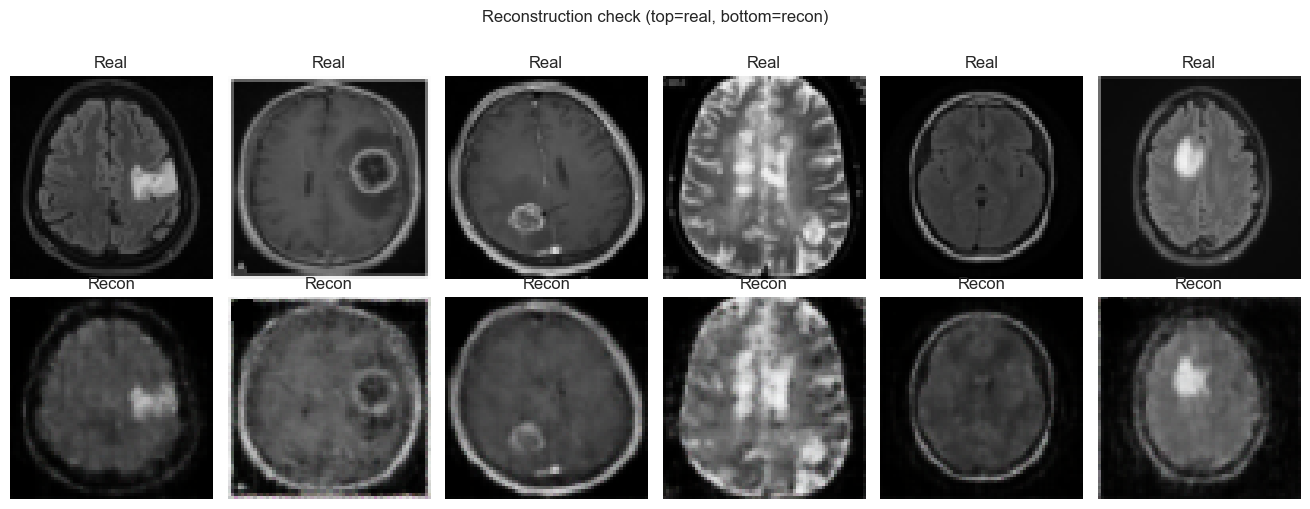

In [ ]:
# ==========================================
# Reconstruction sanity check (original vs recon)
# ==========================================
eval_model = model._module if hasattr(model, "_module") else model

eval_model.eval()
num_examples = min(6, len(X))
example_idx = torch.randperm(len(X))[:num_examples]
real_batch = X[example_idx].to(device)

with torch.no_grad():
    recon_batch = eval_model(real_batch).clamp(0.0, 1.0)

fig, axes = plt.subplots(2, num_examples, figsize=(num_examples * 2.2, 5))
for i in range(num_examples):
    axes[0, i].imshow(np.transpose(real_batch[i].cpu().numpy(), (1, 2, 0)))
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.transpose(recon_batch[i].cpu().numpy(), (1, 2, 0)))
    axes[1, i].set_title("Recon")
    axes[1, i].axis("off")

plt.suptitle("Reconstruction check (top=real, bottom=recon)", y=1.02)
plt.tight_layout()
plt.show()



## Latent space structure
Project latent vectors to 2D with PCA and color by class (yes/no tumor) to see whether the VAE separates modes and whether DP noise harms clustering.


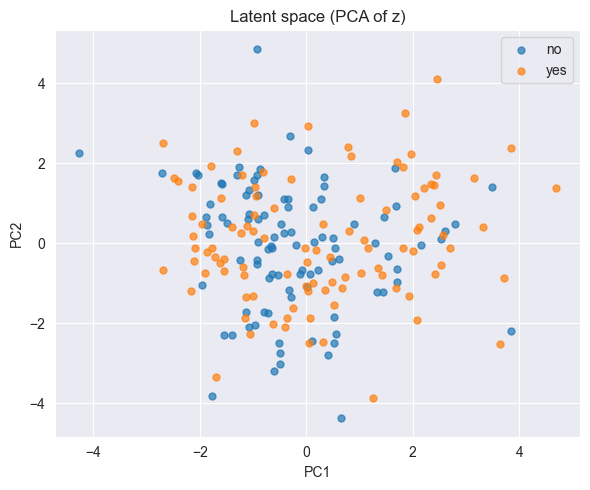

In [ ]:
# ==========================================
# Latent space visualization (PCA -> 2D)
# ==========================================
eval_model = model._module if hasattr(model, "_module") else model
eval_model.eval()

subset = min(len(X), 200)
x_subset = X[:subset].to(device)
labels_subset = y[:subset].cpu().numpy()

with torch.no_grad():
    z_subset = eval_model.encoder(x_subset).cpu().numpy()

pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_subset)

plt.figure(figsize=(6, 5))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
for lbl in np.unique(labels_subset):
    mask = labels_subset == lbl
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=25, alpha=0.7,
                color=colors[int(lbl) % len(colors)], label=LABEL_NAMES.get(int(lbl), str(lbl)))

plt.title("Latent space (PCA of z)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()



## Synthetic sample quality analytics
Lightweight, dependency-free diagnostics to quantify how synthetic images compare to the training data: pixel stats, a Fréchet-style proxy, diversity, and coverage of the real distribution.


In [ ]:
# ==========================================
# Synthetic data quality metrics (no heavy dependencies)
# ==========================================
eval_model = model._module if hasattr(model, "_module") else model
eval_model.eval()

num_real = min(len(X), 128)
num_fake = 128

with torch.no_grad():
    decoder_func = eval_model.decode if hasattr(eval_model, "decode") else model.decode
    syn_eval = decoder_func(torch.randn(num_fake, LATENT_DIM, device=device)).clamp(0.0, 1.0)
real_eval = X[:num_real].to(device)


def feature_pool(tensor, out_hw=8):
    """Downsample feature space for stable statistics."""
    pooled = F.adaptive_avg_pool2d(tensor, (out_hw, out_hw))
    return pooled.cpu().view(pooled.size(0), -1).numpy()


def fid_proxy(feat_real, feat_fake):
    """Frechet-like distance on pooled features (lower = closer)."""
    mu_r, mu_f = feat_real.mean(axis=0), feat_fake.mean(axis=0)
    cov_r, cov_f = np.cov(feat_real, rowvar=False), np.cov(feat_fake, rowvar=False)
    return float(np.linalg.norm(mu_r - mu_f) + np.linalg.norm(cov_r - cov_f))


def diversity_score(features):
    """Average pairwise distance inside a set (higher = more diverse)."""
    dists = pairwise_distances(features)
    upper = dists[np.triu_indices_from(dists, k=1)]
    return float(upper.mean())


real_feat = feature_pool(real_eval)
fake_feat = feature_pool(syn_eval)

real_stats = {
    "pixel_mean": float(real_eval.mean()),
    "pixel_std": float(real_eval.std()),
    "channel_means": real_eval.mean(dim=[0, 2, 3]).cpu().numpy().round(3).tolist(),
}
fake_stats = {
    "pixel_mean": float(syn_eval.mean()),
    "pixel_std": float(syn_eval.std()),
    "channel_means": syn_eval.mean(dim=[0, 2, 3]).cpu().numpy().round(3).tolist(),
}

fid_score = fid_proxy(real_feat, fake_feat)
div_real = diversity_score(real_feat)
div_fake = diversity_score(fake_feat)
coverage = float(np.mean(np.min(pairwise_distances(fake_feat, real_feat), axis=1)))

print("Real stats:", real_stats)
print("Synthetic stats:", fake_stats)
print(f"FID-like proxy (lower = closer): {fid_score:.3f}")
print(f"Diversity | real: {div_real:.3f} | synthetic: {div_fake:.3f}")
print(f"Coverage (avg NN dist synthetic->real, lower = better): {coverage:.3f}")



Real stats: {'pixel_mean': 0.22150151431560516, 'pixel_std': 0.2131417840719223, 'channel_means': [0.22200000286102295, 0.22200000286102295, 0.22100000083446503]}
Synthetic stats: {'pixel_mean': 0.2071092575788498, 'pixel_std': 0.1726272851228714, 'channel_means': [0.2070000022649765, 0.2070000022649765, 0.2070000022649765]}
FID-like proxy (lower = closer): 1.247
Diversity | real: 2.107 | synthetic: 1.446
Coverage (avg NN dist synthetic->real, lower = better): 0.660
